<a href="https://colab.research.google.com/github/bilgeyucel/haystack-cookbook/blob/main/notebooks/processing_different_file_types.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preprocessing Different File Types for RAG using Pinecone and Haystack

- **Level**: Beginner
- **Time to complete**: 10 minutes

**📚 Useful Sources:**
* [Docs: PineconeDocumentStore](https://docs.haystack.deepset.ai/docs/pinecone-document-store)
* [Integration: Pinecone](https://haystack.deepset.ai/integrations/pinecone-document-store)

## Overview

In this notebook, you'll build an indexing pipeline that preprocesses different types of files (markdown, txt and pdf). Each file will have its own `FileConverter`. The rest of the indexing pipeline is fairly standard - split the documents into chunks, trim whitespace, create embeddings and write them to a Document Store. Then, you'll use these documents in a RAG pipeline.

>[Preprocessing Different File Types for RAG using Pinecone and Haystack](#scrollTo=zAKy_OPy81EZ)

>>[Overview](#scrollTo=zAKy_OPy81EZ)

>>[Components Used](#scrollTo=96w6PrcPk4Fc)

>>[Installing dependencies](#scrollTo=_pG2jycZLYYr)

>>[Connect to Pinecone](#scrollTo=pClWKhddqSNX)

>>[Download All Files](#scrollTo=7GWbC28fX0Yp)

>>[Create a Pipeline to Index Documents](#scrollTo=DH8HEymp6XFZ)

>>[Build a pipeline to query documents](#scrollTo=QASEGJhnIMQL)

>>[What's next](#scrollTo=zA7xHckYJHsG)



## Components Used

- [`FileTypeRouter`](https://docs.haystack.deepset.ai/docs/filetyperouter): To route files based on their corresponding MIME type to different components
- [`MarkdownToDocument`](https://docs.haystack.deepset.ai/docs/markdowntodocument): To convert markdown files into Haystack Documents
- [`PyPDFToDocument`](https://docs.haystack.deepset.ai/docs/pypdftodocument): To convert PDF files into Haystack Documents
- [`TextFileToDocument`](https://docs.haystack.deepset.ai/docs/textfiletodocument): To convert text files into Haystack Documents
- [`DocumentJoiner`](https://docs.haystack.deepset.ai/docs/documentjoiner): To join Documents coming from different branches of a pipeline
- [`DocumentCleaner`](https://docs.haystack.deepset.ai/docs/documentcleaner) (optional): To make Documents more readable by removing extra whitespaces etc.
- [`DocumentSplitter`](https://docs.haystack.deepset.ai/docs/documentsplitter): To split your Document into chunks
- [`OpenAIDocumentEmbedder`](https://docs.haystack.deepset.ai/docs/openaidocumentembedder): To create embeddings for Documents
- [`DocumentWriter`](https://docs.haystack.deepset.ai/docs/documentwriter): To write Documents into the DocumentStore
- [`OpenAITextEmbedder`](https://docs.haystack.deepset.ai/docs/openaitextembedder): To create embedding for query
- [`PineconeEmbeddingRetriever`](https://docs.haystack.deepset.ai/docs/pineconedenseretriever): To retrieve data from PineconeDocumentStore
- [`PromptBuilder`](https://docs.haystack.deepset.ai/docs/promptbuilder): To render a prompt template and fill in variable value.
- [`OpenAIGenerator`](https://docs.haystack.deepset.ai/docs/openaigenerator)`: To generate text using OpenAI's large language models

## Installing dependencies


In [ ]:
%%bash
pip install haystack-ai
pip install pinecone-haystack
pip install markdown-it-py mdit_plain pypdf
pip install gdown

In [ ]:
import os
from getpass import getpass

if "OPENAI_API_KEY" not in os.environ:
    os.environ["OPENAI_API_KEY"] = getpass("Enter OPENAI_API_KEY:")
if "PINECONE_API_KEY" not in os.environ:
    os.environ["PINECONE_API_KEY"] = getpass("Enter PINECONE_API_KEY:")

Enter PINECONE_API_KEY:··········


## Connect to Pinecone

Initialize a `PineconeDocumentStore` for Haystack

In [ ]:
from haystack_integrations.document_stores.pinecone import PineconeDocumentStore

# Make sure you have the PINECONE_API_KEY environment variable set
# Environment should be "gcp-starter" if you're using free tier
# Give a new name for the index
document_store = PineconeDocumentStore(metric="cosine", dimension=1536, index="pinecone-docs-test-2", environment="gcp-starter")

## Download All Files

Files that you will use in this tutorial are stored in a [GDrive folder](https://drive.google.com/drive/folders/1n9yqq5Gl_HWfND5bTlrCwAOycMDt5EMj). Either download files directly from the GDrive folder or run the code below. If you're running this tutorial on colab, you'll find the downloaded files under "/recipe_files" folder in "files" tab on the left.

Just like most real life data, these files are a mishmash of different types.

In [ ]:
import gdown

url = "https://drive.google.com/drive/folders/1n9yqq5Gl_HWfND5bTlrCwAOycMDt5EMj"
output_dir = "recipe_files"

gdown.download_folder(url, quiet=True, output=output_dir)

['recipe_files/vegan_flan_recipe.md',
 'recipe_files/vegan_keto_eggplant_recipe.pdf',
 'recipe_files/vegan_sunflower_hemp_cheese_recipe.txt']

## Create a Pipeline to Index Documents

Next, you'll create a pipeline to index documents.

You'll need a different file converter class for each file type in our data sources: `.pdf`, `.txt`, and `.md` in this case. Our `FileTypeRouter` connects each file type to the proper converter.

Once all our files have been converted to Haystack Documents, we can use the `DocumentJoiner` component to make these a single list of documents that can be fed through the rest of the indexing pipeline all together.

In [ ]:
from haystack.components.writers import DocumentWriter
from haystack.components.converters import MarkdownToDocument, PyPDFToDocument, TextFileToDocument
from haystack.components.preprocessors import DocumentSplitter, DocumentCleaner
from haystack.components.routers import FileTypeRouter
from haystack.components.joiners import DocumentJoiner
from haystack.components.embedders import OpenAIDocumentEmbedder
from haystack import Pipeline

file_type_router = FileTypeRouter(mime_types=["text/plain", "application/pdf", "text/markdown"])
text_file_converter = TextFileToDocument()
markdown_converter = MarkdownToDocument()
pdf_converter = PyPDFToDocument()
document_joiner = DocumentJoiner()

From there, the steps to this indexing pipeline are a bit more standard. The `DocumentCleaner` removes whitespace. Then this `DocumentSplitter` breaks them into chunks of 150 words, with a bit of overlap to avoid missing context.

In [ ]:
document_cleaner = DocumentCleaner()
document_splitter = DocumentSplitter(split_by="word", split_length=150, split_overlap=50)

Now you'll add a `SentenceTransformersDocumentEmbedder` to create embeddings from the documents. As the last step in this pipeline, the `DocumentWriter` will write them to the `InMemoryDocumentStore`.


In [ ]:
document_embedder = OpenAIDocumentEmbedder(model="text-embedding-3-small")
document_writer = DocumentWriter(document_store)

After creating all the components, add them to the indexing pipeline.

In [ ]:
preprocessing_pipeline = Pipeline()
preprocessing_pipeline.add_component(instance=file_type_router, name="file_type_router")
preprocessing_pipeline.add_component(instance=text_file_converter, name="text_file_converter")
preprocessing_pipeline.add_component(instance=markdown_converter, name="markdown_converter")
preprocessing_pipeline.add_component(instance=pdf_converter, name="pypdf_converter")
preprocessing_pipeline.add_component(instance=document_joiner, name="document_joiner")
preprocessing_pipeline.add_component(instance=document_cleaner, name="document_cleaner")
preprocessing_pipeline.add_component(instance=document_splitter, name="document_splitter")
preprocessing_pipeline.add_component(instance=document_embedder, name="document_embedder")
preprocessing_pipeline.add_component(instance=document_writer, name="document_writer")

Next, connect them 👇

In [ ]:
preprocessing_pipeline.connect("file_type_router.text/plain", "text_file_converter.sources")
preprocessing_pipeline.connect("file_type_router.application/pdf", "pypdf_converter.sources")
preprocessing_pipeline.connect("file_type_router.text/markdown", "markdown_converter.sources")
preprocessing_pipeline.connect("text_file_converter", "document_joiner")
preprocessing_pipeline.connect("pypdf_converter", "document_joiner")
preprocessing_pipeline.connect("markdown_converter", "document_joiner")
preprocessing_pipeline.connect("document_joiner", "document_cleaner")
preprocessing_pipeline.connect("document_cleaner", "document_splitter")
preprocessing_pipeline.connect("document_splitter", "document_embedder")
preprocessing_pipeline.connect("document_embedder", "document_writer")

🚅 Components
  - file_type_router: FileTypeRouter
  - text_file_converter: TextFileToDocument
  - markdown_converter: MarkdownToDocument
  - pypdf_converter: PyPDFToDocument
  - document_joiner: DocumentJoiner
  - document_cleaner: DocumentCleaner
  - document_splitter: DocumentSplitter
  - document_embedder: OpenAIDocumentEmbedder
  - document_writer: DocumentWriter
🛤️ Connections
  - file_type_router.text/plain -> text_file_converter.sources (List[Path])
  - file_type_router.application/pdf -> pypdf_converter.sources (List[Path])
  - file_type_router.text/markdown -> markdown_converter.sources (List[Path])
  - text_file_converter.documents -> document_joiner.documents (List[Document])
  - markdown_converter.documents -> document_joiner.documents (List[Document])
  - pypdf_converter.documents -> document_joiner.documents (List[Document])
  - document_joiner.documents -> document_cleaner.documents (List[Document])
  - document_cleaner.documents -> document_splitter.documents (List[Docu

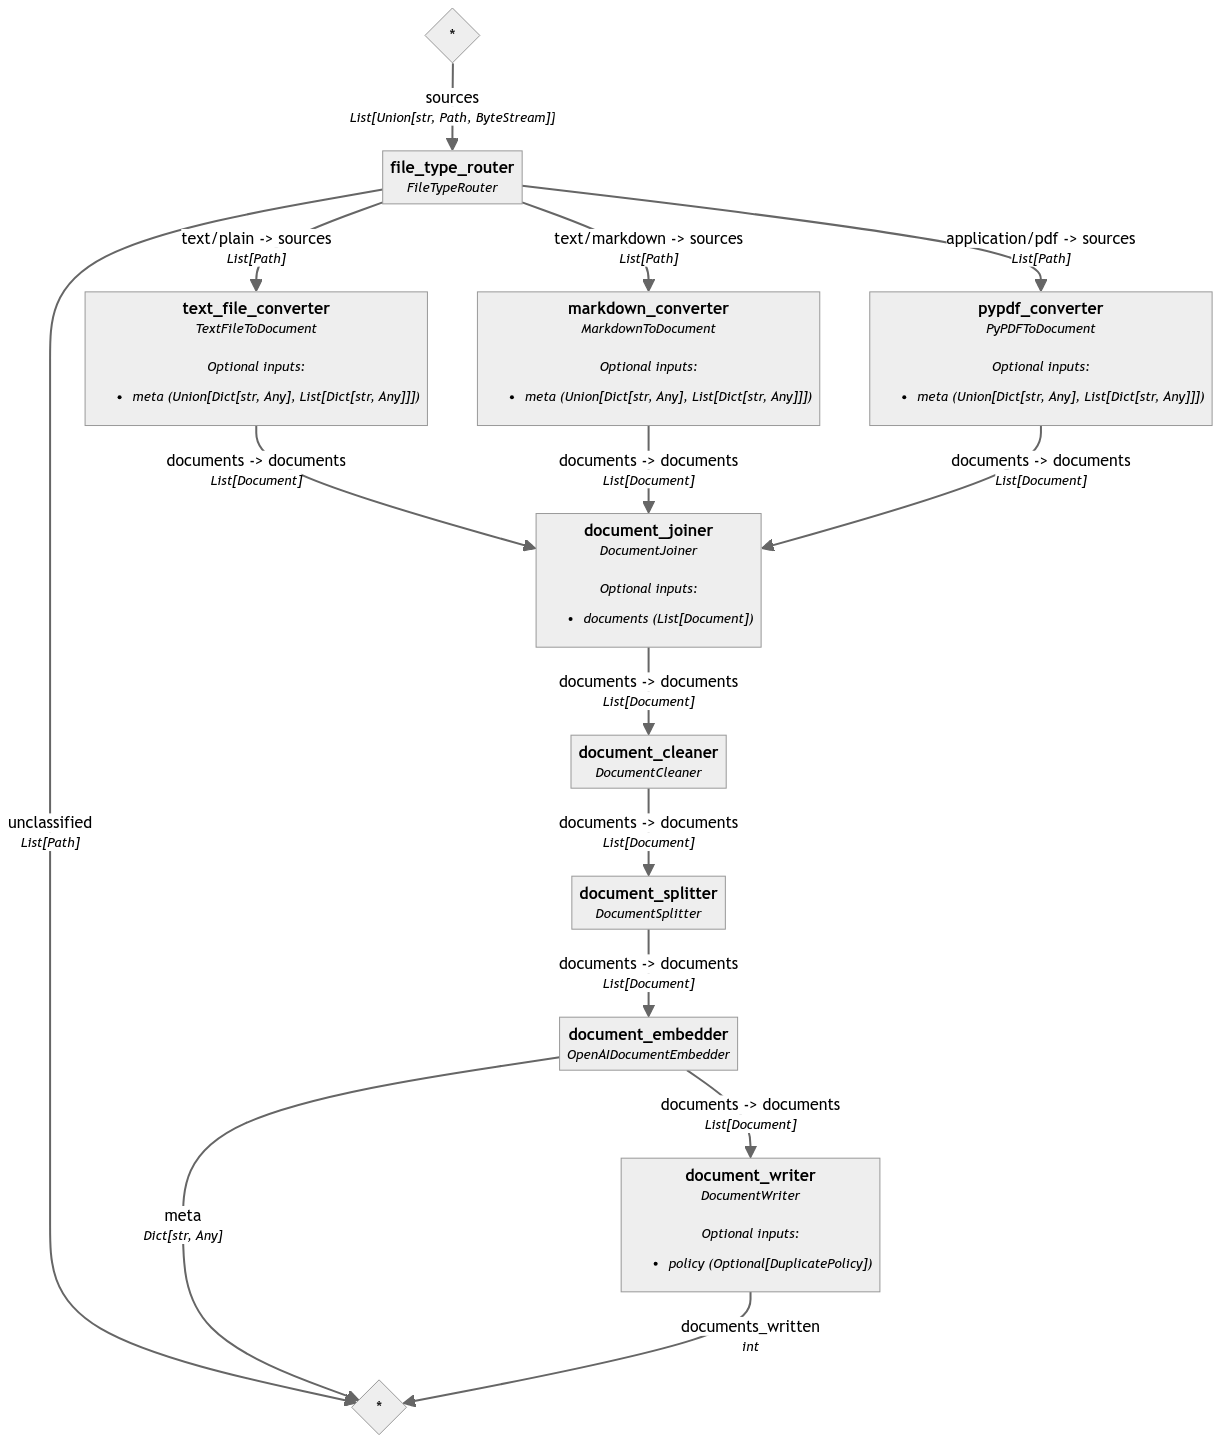

In [ ]:
preprocessing_pipeline.show()

Let's test this pipeline with a few recipes I've written. Are you getting hungry yet?

In [ ]:
from pathlib import Path

preprocessing_pipeline.run({"file_type_router": {"sources": list(Path(output_dir).glob("**/*"))}})

Calculating embeddings: 100%|██████████| 1/1 [00:00<00:00,  1.48it/s]


Upserted vectors:   0%|          | 0/7 [00:00<?, ?it/s]

{'document_embedder': {'meta': {'model': 'text-embedding-3-small',
   'usage': {'prompt_tokens': 2125, 'total_tokens': 2125}}},
 'document_writer': {'documents_written': 7}}

## Build a pipeline to query documents

Now, let's build a RAG pipeline that answers queries based on the documents you just created in the section above.

This pipeline takes the prompt, searches the document store for relevant documents, and passes those documents along to the LLM to formulate an answer.

> ⚠️ Notice how we used `text-embedding-3-small` to create embeddings for our documents before. This is why we will be using the same model to embed incoming questions.

In [ ]:
from haystack.components.embedders import OpenAITextEmbedder
from haystack_integrations.components.retrievers.pinecone import PineconeEmbeddingRetriever
from haystack.components.builders import PromptBuilder
from haystack.components.generators import OpenAIGenerator

template = """
Answer the questions based on the given context.

Context:
{% for document in documents %}
    {{ document.content }}
{% endfor %}

Question: {{ question }}
Answer:
"""
pipe = Pipeline()
pipe.add_component("embedder", OpenAITextEmbedder(model="text-embedding-3-small"))
pipe.add_component("retriever", PineconeEmbeddingRetriever(document_store=document_store))
pipe.add_component("prompt_builder", PromptBuilder(template=template))
pipe.add_component("llm",OpenAIGenerator())

pipe.connect("embedder.embedding", "retriever.query_embedding")
pipe.connect("retriever", "prompt_builder.documents")
pipe.connect("prompt_builder", "llm")

🚅 Components
  - embedder: OpenAITextEmbedder
  - retriever: PineconeEmbeddingRetriever
  - prompt_builder: PromptBuilder
  - llm: OpenAIGenerator
🛤️ Connections
  - embedder.embedding -> retriever.query_embedding (List[float])
  - retriever.documents -> prompt_builder.documents (List[Document])
  - prompt_builder.prompt -> llm.prompt (str)

Try it out yourself by running the code below. If all has gone well, you should have a complete shopping list from all the recipe sources. 🧂🥥🧄

In [ ]:
question = "What ingredients would I need to make vegan keto eggplant lasagna, vegan persimmon flan, and vegan hemp cheese?"

pipe.run({
    "embedder": {"text": question},
    "prompt_builder": {"question": question},
})

{'embedder': {'meta': {'model': 'text-embedding-3-small',
   'usage': {'prompt_tokens': 26, 'total_tokens': 26}}},
 'llm': {'replies': ['To make vegan keto eggplant lasagna, vegan persimmon flan, and vegan hemp cheese, you would need the following ingredients:\n\nVegan Keto Eggplant Lasagna:\n- 2 large eggplants\n- Salt\n- Store-bought vegan mozzarella\n- Basil\n- Almonds\n- Nutritional yeast\n- Olive oil\n- Garlic powder\n- Lemon\n- Macadamia nuts\n- Firm or extra firm tofu\n- Spinach\n- Vegan cheese (optional)\n\nVegan Persimmon Flan:\n- Persimmon pulp\n- Cornstarch\n- Agar agar\n- Agave nectar\n- Granulated sugar\n- Coconut creme\n- Almond milk\n- Vanilla\n\nVegan Hemp Cheese:\n- Sunflower seeds\n- Hemp hearts\n- Miso paste\n- Nutritional yeast\n- Rejuvelac (or kombucha or sauerkraut liquid)\n- Salt'],
  'meta': [{'model': 'gpt-3.5-turbo-0125',
    'index': 0,
    'finish_reason': 'stop',
    'usage': {'completion_tokens': 191,
     'prompt_tokens': 3015,
     'total_tokens': 3206}}

Example output:
```python
{'llm': {'replies': ["\n\nVegan Keto Eggplant Lasagna:\n\nIngredients:\n- 2 large eggplants\n- A lot of salt (you should have this in your house already)\n- 1/2 cup store-bought vegan mozzarella (for topping)\n\nPesto:\n- 4 oz basil (generally one large clamshell or 2 small ones)\n- 1/4 cup almonds\n- 1/4 cup nutritional yeast\n- 1/4 cup olive oil\n- 1 recipe vegan pesto (you can find this in the recipe)\n- 1 recipe spinach tofu ricotta (you can find this in the recipe)\n- 1 tsp garlic powder\n- Juice of half a lemon\n- Salt to taste\n\nSpinach Tofu Ricotta:\n- 10 oz firm or extra firm tofu\n- Juice of 1 lemon\n- Garlic powder to taste\n- Salt to taste\n\nInstructions:\n1. Slice the eggplants into 1/4 inch thick slices. Some slices will need to be scrapped because it's difficult to get them all uniformly thin. Use them in soup or something, IDK, man.\n2. Take the eggplant slices and rub both sides with salt. Don't be shy about how much, you're gonna rinse it off anyway.\n3. Put them in a colander with something underneath it and let them sit for half an hour. This draws the water out so that the egg"],
  'meta': [{'model': 'HuggingFaceH4/zephyr-7b-beta',
    ...
    }]}}
```

## What's next

Congratulations on building an indexing pipeline that can preprocess different file types. Go forth and ingest all the messy real-world data into your workflows. 💥

If you liked this example, you may also enjoy:
- [Serializing Haystack Pipelines](https://haystack.deepset.ai/tutorials/29_serializing_pipelines)
-  [Creating Your First QA Pipeline with Retrieval-Augmentation](https://haystack.deepset.ai/tutorials/27_first_rag_pipeline)

To stay up to date on the latest Haystack developments, you can [sign up for our newsletter](https://landing.deepset.ai/haystack-community-updates) or [join Haystack discord community](https://discord.com/invite/VBpFzsgRVF).

Thanks for reading!